In [1]:
import os
import PIL.Image as Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

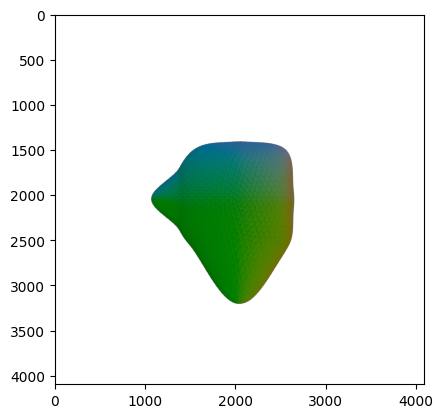

In [2]:
folder_path = "./images-unity/normals/"
folder_path_out = "./images-unity/reshaped/"
size_reshape = 2048
sigma_rotation = 5  # degrees

image_test = Image.open(folder_path + "normal_0.png").convert('RGBA')
image_test = np.array(image_test)
plt.imshow(image_test)
plt.show()

In [3]:
def change_R(img, R):

    R = np.asarray(R, dtype=np.float32)

    img_f = img[:, :, :3].astype(np.float32)

    # masque avec alpha
    alpha = img[:, :, 3]
    mask = alpha > 0

    # reshape pour cv2.transform
    h, w, _ = img.shape
    reshaped = img_f.reshape(-1, 1, 3)

    transformed = cv2.transform(reshaped, R)
    transformed = transformed.reshape(h, w, 3)

    img_out = img_f.copy()
    img_out[mask] = np.clip(transformed[mask], 0, 255)

    # remettre le canal alpha
    img_out = np.dstack((img_out, alpha))

    return img_out.astype(np.uint8)


def get_random_R(range):
    angle_x = random.gauss(0, range)
    angle_y = random.gauss(0, range)
    angle_z = random.gauss(0, range)

    Rx = cv2.Rodrigues(np.array([np.radians(angle_x), 0, 0]))[0]
    Ry = cv2.Rodrigues(np.array([0, np.radians(angle_y), 0]))[0]
    Rz = cv2.Rodrigues(np.array([0, 0, np.radians(angle_z)]))[0]

    R = Rz @ Ry @ Rx
    return R

R: [[ 0.99764648  0.06818511 -0.00723167]
 [-0.06830003  0.99751902 -0.01705617]
 [ 0.00605075  0.01750995  0.99982838]]


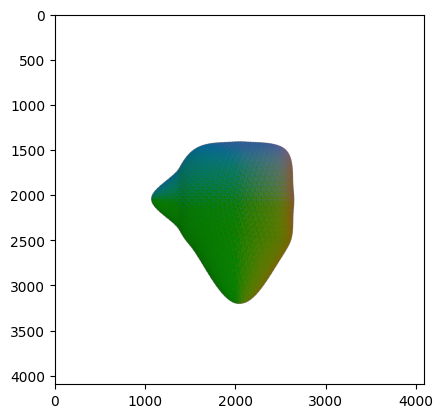

In [4]:
# Matrice de rotation de R360 degrees
R = get_random_R(sigma_rotation)
print("R:", R)

image_test_R = change_R(image_test, R)

plt.imshow(image_test_R)
plt.show()

In [5]:
# trouver le min et le max non nul selon x et y
def crop_image_reshape(image, size):
    mask = image[:, :, 3] > 0       # utiliser le canal alpha comme masque
    coords = np.argwhere(mask)

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1 # ajouter 1 pour inclure le pixel max
    cropped = image[y0:y1, x0:x1]

    cropped = cv2.resize(cropped, (size, size), interpolation=cv2.INTER_AREA)

    return cropped

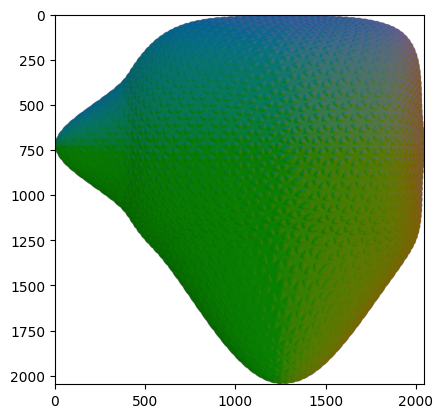

In [6]:
image_test_cropped = crop_image_reshape(image_test_R, 2048)
plt.imshow(image_test_cropped)
plt.show()

In [7]:

# Reset folder
if not os.path.exists(folder_path_out):
    os.makedirs(folder_path_out)

for i, img_name in enumerate(sorted(os.listdir(folder_path))):
    print(f"Processing image {i+1}/{len(os.listdir(folder_path))}: {img_name}")
    img = Image.open(os.path.join(folder_path, img_name)).convert('RGBA')
    img = np.array(img)
    # img = change_R(img, get_random_R(sigma_rotation))
    img = crop_image_reshape(img, size_reshape)
    img_pil = Image.fromarray(img)
    img_name = os.path.splitext(img_name)[0]
    img_pil.save(os.path.join(folder_path_out, f"{img_name}_reshaped.png"))
    

Processing image 1/6: normal_0.png
Processing image 2/6: normal_1.png
Processing image 3/6: normal_2.png
Processing image 4/6: normal_3.png
Processing image 5/6: normal_4.png
Processing image 6/6: normal_5.png
